## Siamese Neural Network from Scratch

A **Siamese network** consists of two identical sub-networks (sharing the same weights) that process two inputs in parallel. The outputs are compared using a distance metric to determine similarity.

**Key Ideas:**
- Both branches share weights → learn a single embedding space
- Trained with pairs: similar (label=1) or dissimilar (label=0)
- Uses **contrastive loss** to pull similar pairs closer and push dissimilar pairs apart in embedding space

**Architecture Flow:**
```
Input A → [Shared Encoder] → Embedding A ─┐
                                           ├─→ Distance → Loss
Input B → [Shared Encoder] → Embedding B ─┘
```

In [0]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

### 1. Embedding Network (Shared Sub-network)

The core building block is the **embedding network** — a neural network that maps raw inputs into a compact embedding vector. Both branches of the Siamese network share this exact same network (same weights).

Design choices:
- Fully-connected layers with BatchNorm and ReLU for stable training
- Dropout for regularization
- Final L2-normalized embedding ensures outputs lie on a unit hypersphere, making Euclidean distance meaningful

In [0]:
class EmbeddingNetwork(nn.Module):
    """
    Shared sub-network that maps an input vector to a lower-dimensional
    embedding space. Both branches of the Siamese net use this same network.
    
    Args:
        input_dim: Dimensionality of the input features
        hidden_dims: List of hidden layer sizes
        embedding_dim: Size of the output embedding vector
        dropout: Dropout probability for regularization
    """
    
    def __init__(self, input_dim: int, hidden_dims: list = [512, 256], 
                 embedding_dim: int = 128, dropout: float = 0.2):
        super().__init__()
        
        layers = []
        prev_dim = input_dim
        
        # Build hidden layers dynamically
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),   # Stabilizes training
                nn.ReLU(inplace=True),
                nn.Dropout(dropout)            # Prevents overfitting
            ])
            prev_dim = hidden_dim
        
        # Final projection to embedding space (no activation — raw embedding)
        layers.append(nn.Linear(prev_dim, embedding_dim))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass: input → L2-normalized embedding."""
        embedding = self.network(x)
        # L2 normalize so embeddings lie on unit hypersphere
        # This makes Euclidean distance equivalent to cosine distance
        embedding = F.normalize(embedding, p=2, dim=1)
        return embedding

print("EmbeddingNetwork defined ✓")

EmbeddingNetwork defined ✓


### 2. Siamese Network

The Siamese network wraps the embedding network and processes **two inputs simultaneously**. Crucially, both branches share weights — we instantiate one `EmbeddingNetwork` and call it twice.

The network outputs:
- Two embeddings (one per input)
- The Euclidean distance between them

At inference time, small distance = similar, large distance = dissimilar.

In [0]:
class SiameseNetwork(nn.Module):
    """
    Siamese Network: processes two inputs through a shared embedding network
    and computes their similarity via Euclidean distance.
    
    The key insight is weight sharing — both inputs pass through the SAME
    network, ensuring they are embedded in the same learned space.
    """
    
    def __init__(self, input_dim: int, hidden_dims: list = [512, 256],
                 embedding_dim: int = 128, dropout: float = 0.2):
        super().__init__()
        
        # Single shared embedding network (weight sharing is automatic
        # since we call the same module for both inputs)
        self.embedding_net = EmbeddingNetwork(
            input_dim=input_dim,
            hidden_dims=hidden_dims,
            embedding_dim=embedding_dim,
            dropout=dropout
        )
    
    def forward_one(self, x: torch.Tensor) -> torch.Tensor:
        """Embed a single input (useful at inference time)."""
        return self.embedding_net(x)
    
    def forward(self, input1: torch.Tensor, input2: torch.Tensor):
        """
        Forward pass for a pair of inputs.
        
        Returns:
            emb1: Embedding of input1
            emb2: Embedding of input2  
            distance: Euclidean distance between the two embeddings
        """
        # Both inputs pass through the SAME network (shared weights)
        emb1 = self.embedding_net(input1)
        emb2 = self.embedding_net(input2)
        
        # Euclidean distance between embeddings
        distance = F.pairwise_distance(emb1, emb2, p=2)
        
        return emb1, emb2, distance

print("SiameseNetwork defined ✓")

SiameseNetwork defined ✓


### 3. Contrastive Loss Function

The standard loss for Siamese networks is **contrastive loss** (Hadsell et al., 2006):

$$\mathcal{L} = (1-y) \cdot \frac{1}{2} d^2 + y \cdot \frac{1}{2} \max(0,\; m - d)^2$$

Where:
- $y = 0$ for similar pairs, $y = 1$ for dissimilar pairs
- $d$ = Euclidean distance between embeddings
- $m$ = margin (minimum distance we want for dissimilar pairs)

**Intuition:**
- **Similar pairs** ($y=0$): Loss increases with distance → pulls embeddings together
- **Dissimilar pairs** ($y=1$): Loss is zero when distance > margin → pushes apart until sufficiently separated, then stops

In [0]:
class ContrastiveLoss(nn.Module):
    """
    Contrastive Loss for Siamese Networks.
    
    Pulls similar pairs together and pushes dissimilar pairs apart
    (up to a margin boundary).
    
    Args:
        margin: Minimum distance threshold for dissimilar pairs.
                Beyond this distance, no gradient is applied.
    """
    
    def __init__(self, margin: float = 2.0):
        super().__init__()
        self.margin = margin
    
    def forward(self, distance: torch.Tensor, label: torch.Tensor) -> torch.Tensor:
        """
        Args:
            distance: Euclidean distance between embedding pairs (batch_size,)
            label: 0 = similar pair, 1 = dissimilar pair (batch_size,)
        
        Returns:
            Scalar loss value
        """
        # Similar pairs: minimize distance (pull together)
        similar_loss = (1 - label) * torch.pow(distance, 2)
        
        # Dissimilar pairs: maximize distance up to margin (push apart)
        dissimilar_loss = label * torch.pow(
            torch.clamp(self.margin - distance, min=0.0), 2
        )
        
        # Average over batch
        loss = 0.5 * torch.mean(similar_loss + dissimilar_loss)
        return loss

print("ContrastiveLoss defined ✓")

ContrastiveLoss defined ✓


### 4. Pair Dataset

Siamese networks require **paired** training data. For each sample we need:
- Two inputs (anchor and comparison)
- A label indicating whether they are similar (0) or dissimilar (1)

The dataset below generates balanced pairs from labeled data — 50% positive (same class) and 50% negative (different class) pairs.

In [0]:
class SiamesePairDataset(Dataset):
    """
    Creates pairs of samples for Siamese training.
    
    For each index, randomly generates either:
    - A positive pair (same class, label=0)
    - A negative pair (different class, label=1)
    
    This ensures balanced training on both similar and dissimilar pairs.
    """
    
    def __init__(self, data: np.ndarray, labels: np.ndarray):
        self.data = torch.FloatTensor(data)
        self.labels = labels
        self.unique_labels = np.unique(labels)
        
        # Index samples by class for efficient pair creation
        self.label_to_indices = {
            label: np.where(labels == label)[0]
            for label in self.unique_labels
        }
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        anchor = self.data[idx]
        anchor_label = self.labels[idx]
        
        # 50% chance of positive pair (same class)
        if np.random.random() > 0.5:
            # Positive pair: pick another sample from the same class
            pos_indices = self.label_to_indices[anchor_label]
            pair_idx = np.random.choice(pos_indices)
            pair_label = 0  # 0 = similar
        else:
            # Negative pair: pick a sample from a different class
            neg_label = np.random.choice(
                [l for l in self.unique_labels if l != anchor_label]
            )
            neg_indices = self.label_to_indices[neg_label]
            pair_idx = np.random.choice(neg_indices)
            pair_label = 1  # 1 = dissimilar
        
        pair = self.data[pair_idx]
        return anchor, pair, torch.FloatTensor([pair_label])

print("SiamesePairDataset defined ✓")

SiamesePairDataset defined ✓


### 5. Training Loop

Below is the complete training pipeline:
1. Generate synthetic data (3 classes in 2D for visualization)
2. Instantiate the Siamese network and contrastive loss
3. Train with Adam optimizer
4. Visualize the learned embedding space

In [0]:
# --- Generate synthetic data (3 clusters in 784-dim space) ---
np.random.seed(42)
n_samples_per_class = 300
input_dim = 784  # e.g., flattened 28x28 images

# Create 3 well-separated clusters
class_0 = np.random.randn(n_samples_per_class, input_dim) * 0.5 + np.random.randn(input_dim) * 3
class_1 = np.random.randn(n_samples_per_class, input_dim) * 0.5 + np.random.randn(input_dim) * 3
class_2 = np.random.randn(n_samples_per_class, input_dim) * 0.5 + np.random.randn(input_dim) * 3

data = np.vstack([class_0, class_1, class_2]).astype(np.float32)
labels = np.array([0]*n_samples_per_class + [1]*n_samples_per_class + [2]*n_samples_per_class)

# --- Setup ---
dataset = SiamesePairDataset(data, labels)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

model = SiameseNetwork(
    input_dim=input_dim,
    hidden_dims=[512, 256],
    embedding_dim=64,
    dropout=0.2
)
criterion = ContrastiveLoss(margin=2.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Training samples: {len(dataset)}")
print(f"Batches per epoch: {len(dataloader)}")

# --- Training ---
num_epochs = 20
model.train()
losses = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for anchor, pair, label in dataloader:
        optimizer.zero_grad()
        _, _, distance = model(anchor, pair)
        loss = criterion(distance, label.squeeze())
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

print("\nTraining complete ✓")

Model parameters: 551,232
Training samples: 900
Batches per epoch: 15
Epoch [5/20] | Loss: 0.0288
Epoch [10/20] | Loss: 0.0248
Epoch [15/20] | Loss: 0.0596
Epoch [20/20] | Loss: 0.0733

Training complete ✓


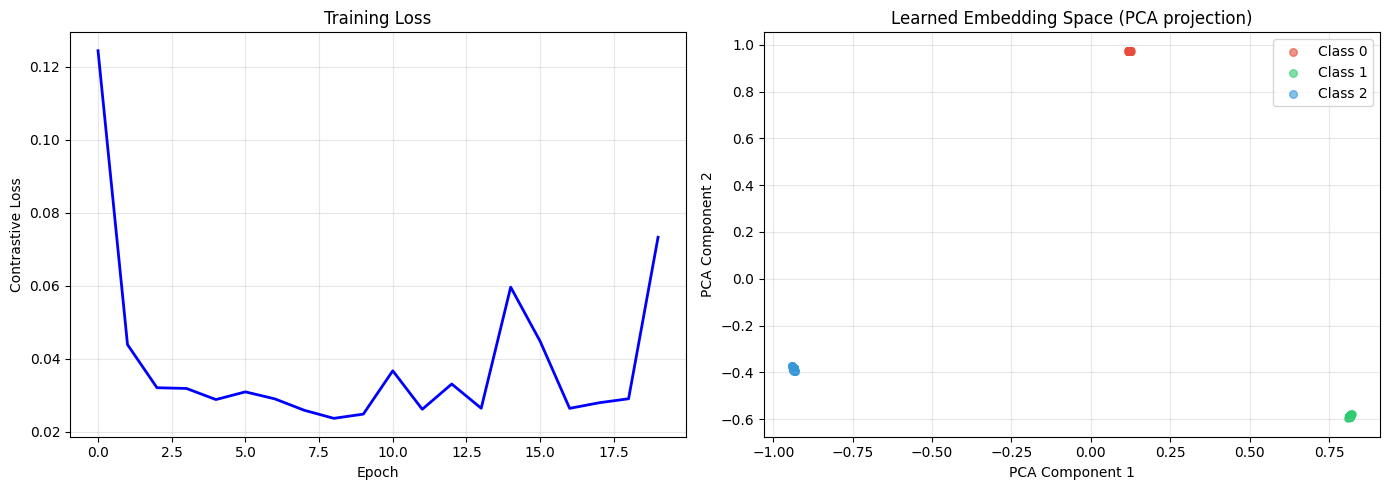


The Siamese network has learned to cluster same-class samples
together while separating different classes in embedding space.


In [0]:
# --- Visualize results ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training loss curve
axes[0].plot(losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Contrastive Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

# Plot 2: Learned embedding space (project to 2D via PCA)
model.eval()
with torch.no_grad():
    embeddings = model.forward_one(torch.FloatTensor(data)).numpy()

# Simple PCA to 2D for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)

colors = ['#e74c3c', '#2ecc71', '#3498db']
for i in range(3):
    mask = labels == i
    axes[1].scatter(emb_2d[mask, 0], emb_2d[mask, 1], 
                   c=colors[i], label=f'Class {i}', alpha=0.6, s=30)

axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
axes[1].set_title('Learned Embedding Space (PCA projection)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nThe Siamese network has learned to cluster same-class samples")
print("together while separating different classes in embedding space.")

---
## Triplet Loss Variant

Triplet loss (Schroff et al., 2015 — FaceNet) uses **three** samples per training step instead of two:

- **Anchor (A)**: reference sample
- **Positive (P)**: same class as anchor
- **Negative (N)**: different class from anchor

$$\mathcal{L} = \max\big(0,\; d(A, P) - d(A, N) + \text{margin}\big)$$

**Intuition:** The anchor should be closer to the positive than to the negative by at least `margin`. This learns a *relative* ordering, which often produces better embeddings than pairwise contrastive loss.

**Hard Mining Strategies:**
- *Hard negative*: closest wrong-class sample (most informative but can destabilize)
- *Semi-hard negative*: farther than positive but within margin (best balance)
- *Random*: any wrong-class sample (stable but slower convergence)

In [0]:
class TripletLoss(nn.Module):
    """
    Triplet Loss: ensures anchor is closer to positive than negative
    by at least a margin.
    
    L = max(0, d(anchor, positive) - d(anchor, negative) + margin)
    
    Compared to contrastive loss:
    - Uses 3 samples (not 2) per training step
    - Learns relative ordering (not absolute distances)
    - Generally produces better-separated embeddings
    
    Args:
        margin: Minimum gap between positive and negative distances
    """
    
    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin
    
    def forward(self, anchor: torch.Tensor, positive: torch.Tensor, 
                negative: torch.Tensor) -> torch.Tensor:
        """
        Args:
            anchor: Embedding of anchor samples (batch_size, emb_dim)
            positive: Embedding of positive samples (batch_size, emb_dim)
            negative: Embedding of negative samples (batch_size, emb_dim)
        
        Returns:
            Scalar loss value
        """
        # Distance from anchor to positive (should be small)
        dist_pos = F.pairwise_distance(anchor, positive, p=2)
        
        # Distance from anchor to negative (should be large)
        dist_neg = F.pairwise_distance(anchor, negative, p=2)
        
        # Triplet loss: push d(A,P) below d(A,N) by at least margin
        losses = torch.relu(dist_pos - dist_neg + self.margin)
        
        return losses.mean()

print("TripletLoss defined ✓")

### Triplet Mining Dataset

For each anchor, we mine:
- A **positive** from the same class
- A **negative** from a different class

This implementation uses random mining. In production, semi-hard or hard mining (selecting negatives within the margin) significantly improves convergence.

In [0]:
class TripletDataset(Dataset):
    """
    Generates (anchor, positive, negative) triplets from labeled data.
    
    Mining strategy: Random selection.
    - Positive: random sample from the same class as anchor
    - Negative: random sample from a different class
    
    For better training, replace with semi-hard or hard mining
    (select negatives that are close to the anchor but wrong class).
    """
    
    def __init__(self, data: np.ndarray, labels: np.ndarray):
        self.data = torch.FloatTensor(data)
        self.labels = labels
        self.unique_labels = np.unique(labels)
        
        # Index samples by class for efficient triplet creation
        self.label_to_indices = {
            label: np.where(labels == label)[0]
            for label in self.unique_labels
        }
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        anchor = self.data[idx]
        anchor_label = self.labels[idx]
        
        # Positive: random sample from the same class (excluding self)
        pos_indices = self.label_to_indices[anchor_label]
        pos_idx = idx
        while pos_idx == idx:  # Ensure we don't pick the anchor itself
            pos_idx = np.random.choice(pos_indices)
        positive = self.data[pos_idx]
        
        # Negative: random sample from a different class
        neg_label = np.random.choice(
            [l for l in self.unique_labels if l != anchor_label]
        )
        neg_idx = np.random.choice(self.label_to_indices[neg_label])
        negative = self.data[neg_idx]
        
        return anchor, positive, negative

print("TripletDataset defined ✓")

In [0]:
# --- Train Siamese network with Triplet Loss ---
triplet_dataset = TripletDataset(data, labels)
triplet_loader = DataLoader(triplet_dataset, batch_size=64, shuffle=True)

# Fresh model (same architecture, new weights)
model_triplet = SiameseNetwork(
    input_dim=input_dim,
    hidden_dims=[512, 256],
    embedding_dim=64,
    dropout=0.2
)
triplet_criterion = TripletLoss(margin=1.0)
optimizer_triplet = torch.optim.Adam(model_triplet.parameters(), lr=1e-3, weight_decay=1e-5)

print(f"Training with Triplet Loss (margin=1.0)...")
print(f"{'='*45}")

# --- Training ---
num_epochs = 20
model_triplet.train()
triplet_losses = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for anchor, positive, negative in triplet_loader:
        optimizer_triplet.zero_grad()
        
        # Embed all three through the shared network
        emb_anchor = model_triplet.forward_one(anchor)
        emb_positive = model_triplet.forward_one(positive)
        emb_negative = model_triplet.forward_one(negative)
        
        loss = triplet_criterion(emb_anchor, emb_positive, emb_negative)
        loss.backward()
        optimizer_triplet.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(triplet_loader)
    triplet_losses.append(avg_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Triplet Loss: {avg_loss:.4f}")

print("\nTriplet training complete ✓")

In [0]:
# --- Compare Contrastive vs Triplet embeddings side-by-side ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss curves comparison
axes[0].plot(losses, 'b-', linewidth=2, label='Contrastive Loss')
axes[0].plot(triplet_losses, 'r-', linewidth=2, label='Triplet Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Contrastive embedding space
model.eval()
with torch.no_grad():
    emb_contrastive = model.forward_one(torch.FloatTensor(data)).numpy()
emb_2d_contrastive = PCA(n_components=2).fit_transform(emb_contrastive)

for i in range(3):
    mask = labels == i
    axes[1].scatter(emb_2d_contrastive[mask, 0], emb_2d_contrastive[mask, 1],
                   c=colors[i], label=f'Class {i}', alpha=0.6, s=30)
axes[1].set_title('Contrastive Loss Embeddings')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Triplet embedding space
model_triplet.eval()
with torch.no_grad():
    emb_triplet = model_triplet.forward_one(torch.FloatTensor(data)).numpy()
emb_2d_triplet = PCA(n_components=2).fit_transform(emb_triplet)

for i in range(3):
    mask = labels == i
    axes[2].scatter(emb_2d_triplet[mask, 0], emb_2d_triplet[mask, 1],
                   c=colors[i], label=f'Class {i}', alpha=0.6, s=30)
axes[2].set_title('Triplet Loss Embeddings')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey differences:")
print("• Contrastive loss: optimizes absolute distances between pairs")
print("• Triplet loss: optimizes relative ordering (anchor closer to pos than neg)")
print("• Triplet often yields tighter, more separable clusters in practice")